## Red Neuronal

En este notebook se entrenara una red neuronal multicapa.

La curva de aprendizaje del codigo en el Modelo_V1, muestra que 5000 audios son la mejor alternativa a usar, esto considerando que el data set tiene aproximadamente 2,500 audios reales y dado que consideramos la estrategia de downsizing de la clase mayoritaria mejor que el oversampling en la minoritaria.

Procedeemos a entrenar una red neuronal usando 5,000 audios.

Importamos las linrerias a usar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score
)
from sklearn.inspection import permutation_importance

SEED = 42
DATA_PATH = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df['label'].value_counts())

Shape: (25380, 36)
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


## Separación del data set en train y test (80/20) 

In [3]:
# Separamos las features númericas de la variable objetivo
feature_cols = [c for c in df.columns if c not in ('file_name', 'label')]
X = df[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(df['label'].values)  # bonafide=0, spoof=1
print('Clases:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Clases: {'bonafide': np.int64(0), 'spoof': np.int64(1)}
Train: (20304, 34) | Test: (5076, 34)


## Balanceo del conjunto de datos

Al separar entre train y test, el subconjunto de entrenamiento queda con menos de 2500 audios reales, por lo que aplicaremos el downsizing tomando como máximo N = min(2500, bonafide_train, spoof_train) por clase, asi seguimos trabajando con un conjunto balanceado y sin agregar datos artificiales a la categoria minoritaria.

In [4]:
idx_bonafide = np.where(y_train == 0)[0]
idx_spoof    = np.where(y_train == 1)[0]

print(f'Disponibles en train — bonafide: {len(idx_bonafide)}, spoof: {len(idx_spoof)}')

N = min(2500, len(idx_bonafide), len(idx_spoof))
print(f'Usando {N} muestras por clase ({N*2} total)')

rng = np.random.default_rng(SEED)
idx_bon_sample   = rng.choice(idx_bonafide, size=N, replace=False)
idx_spoof_sample = rng.choice(idx_spoof,    size=N, replace=False)

idx_bal     = np.concatenate([idx_bon_sample, idx_spoof_sample])
X_train_bal = X_train[idx_bal]
y_train_bal = y_train[idx_bal]

print(f'Train balanceado: {X_train_bal.shape}')
print(f'  bonafide : {(y_train_bal == 0).sum()}')
print(f'  spoof    : {(y_train_bal == 1).sum()}')



Disponibles en train — bonafide: 2064, spoof: 18240
Usando 2064 muestras por clase (4128 total)
Train balanceado: (4128, 34)
  bonafide : 2064
  spoof    : 2064


## Escalado de features

Usamos standarscaler para normalizar las features del conjunto balanceado

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)


In [6]:
# Arquitectura: 34 → 128 → 64 → 32 → 1
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,           # L2 regularization
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

mlp.fit(X_train_sc, y_train_bal)
print(f'Épocas entrenadas  : {mlp.n_iter_}')
print(f'Mejor loss val     : {mlp.best_validation_score_:.4f}')


Épocas entrenadas  : 34
Mejor loss val     : 0.9564


## Curva loss

Graficamos la curva de log loss para ver las iteraciones y el log-loss de la ed neuronal y verificar si nuestro modelo aprende progresivamente y converge.

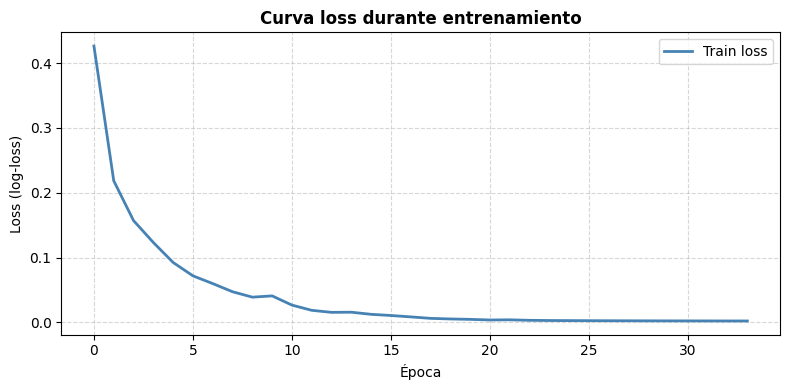

Épocas entrenadas       : 34
Mejor score validación  : 0.9564


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label='Train loss', color='steelblue', linewidth=2)
ax.set_title('Curva loss durante entrenamiento', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (log-loss)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Épocas entrenadas       : {mlp.n_iter_}')
print(f'Mejor score validación  : {mlp.best_validation_score_:.4f}')



La curva baja rapido y se aplana suavemente por lo que hemos verificado que nuestro modelo aprendió bien y llego a un punto estable.

Lo que significa que las features que tenemos son suficientemente claras para distinguir entre real y fake sin tener que hacer muchas iteraciones.

Classification Report

In [8]:
y_pred = mlp.predict(X_test_sc)
y_prob = mlp.predict_proba(X_test_sc)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-macro: {f1_score(y_test, y_pred, average="macro"):.4f}')


=== Classification Report ===
              precision    recall  f1-score   support

    bonafide       0.68      0.97      0.80       516
       spoof       1.00      0.95      0.97      4560

    accuracy                           0.95      5076
   macro avg       0.84      0.96      0.89      5076
weighted avg       0.96      0.95      0.95      5076

ROC-AUC : 0.9899
F1-macro: 0.8851


Matriz de confusión y Curva ROC

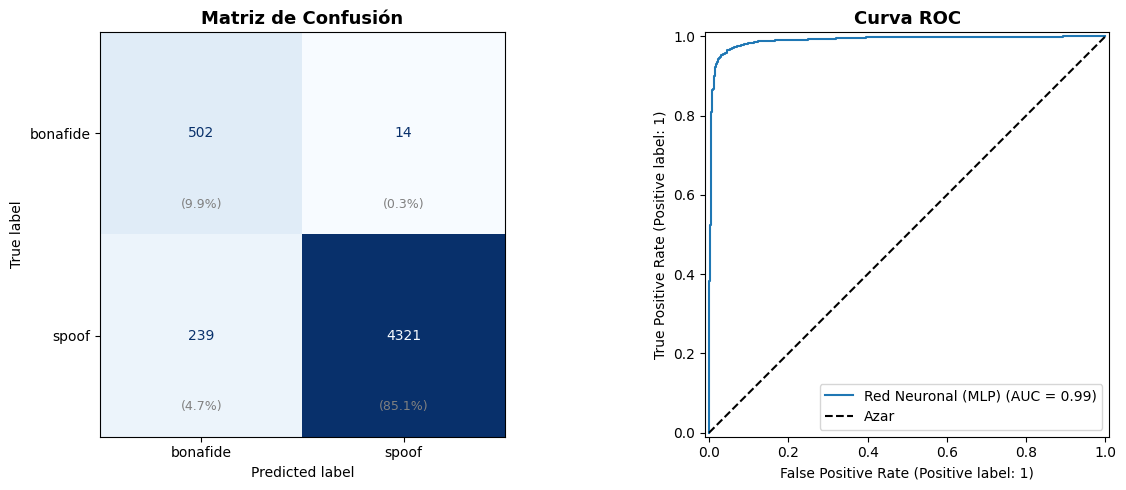

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontweight='bold', fontsize=13)

# Anotar porcentajes
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i + 0.35, f'({cm[i,j]/total*100:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='Red Neuronal (MLP)')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC', fontweight='bold', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()


## Feature Importance

Calcularemos el feature importance usando permutacion importance, el cual revuelve aleatoriamente cada feature 10 veces y mide cuanto cae el ROC-AUC. 

Una caida grande significa que la feature que se quito es altamente discriminatoria, osea que es importante en el modelo. Por el contrario, si no ocurre ningun cambio, significa que esa feature no es importante.

In [10]:
print('Calculando permutation importance (puede tardar ~1 min)...')
perm = permutation_importance(
    mlp, X_test_sc, y_test,
    n_repeats=10,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1
)

fi = pd.DataFrame({
    'feature'   : feature_cols,
    'importance' : perm.importances_mean,
    'std'        : perm.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 features:')
print(fi.head(10).to_string(index=False))


Calculando permutation importance (puede tardar ~1 min)...


Top 10 features:
                feature  importance      std
              rmse_mean    0.033280 0.003162
            mfcc_7_mean    0.030238 0.002657
               zcr_mean    0.021160 0.001018
spectral_bandwidth_mean    0.017617 0.001571
           mfcc_13_mean    0.016323 0.001187
            mfcc_6_mean    0.012604 0.001402
            mfcc_8_mean    0.012270 0.000879
             mfcc_2_std    0.011093 0.001433
             signal_std    0.010863 0.001091
            mfcc_5_mean    0.010576 0.001351


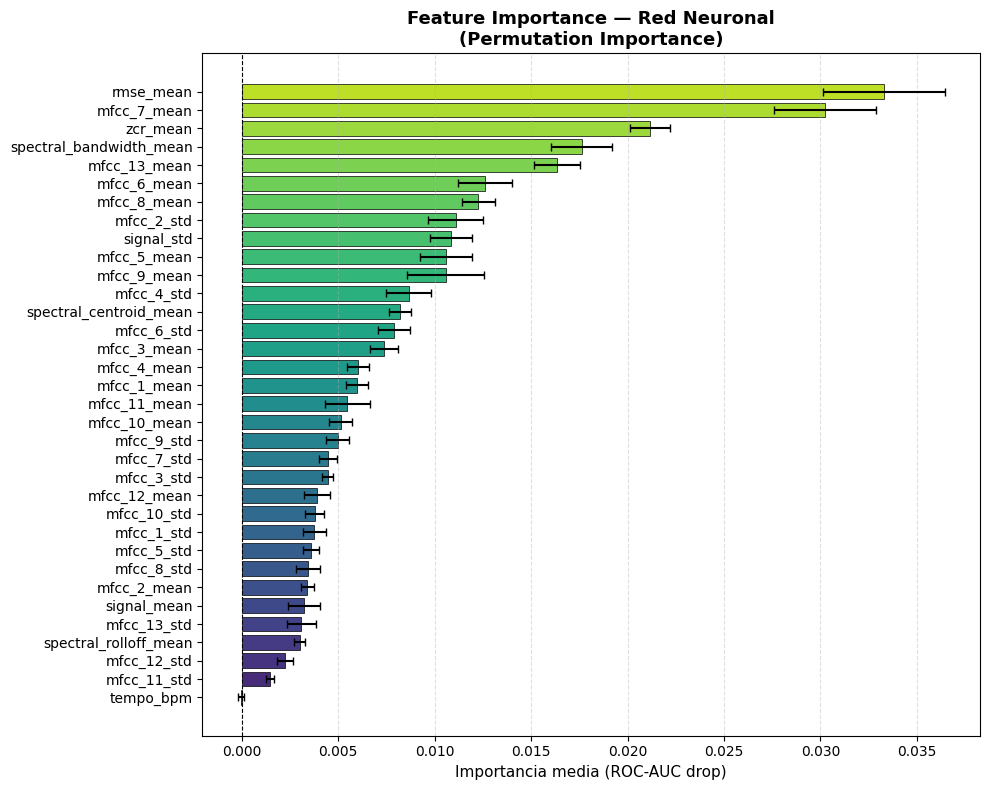

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(fi)))
ax.barh(fi['feature'][::-1], fi['importance'][::-1],
        xerr=fi['std'][::-1], color=colors[::-1],
        edgecolor='black', linewidth=0.5, capsize=3)
ax.set_xlabel('Importancia media (ROC-AUC drop)', fontsize=11)
ax.set_title('Feature Importance — Red Neuronal\n(Permutation Importance)',
             fontweight='bold', fontsize=13)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



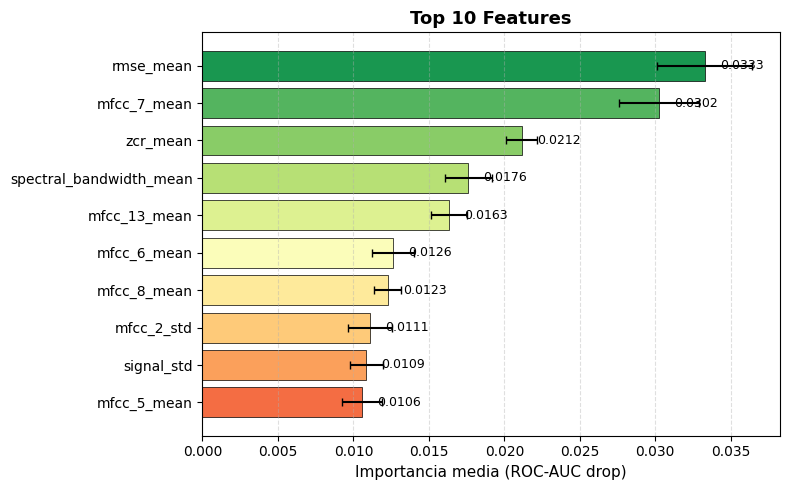

In [12]:
top10 = fi.head(10)
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 10))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['feature'][::-1], top10['importance'][::-1],
        xerr=top10['std'][::-1], color=palette,
        edgecolor='black', linewidth=0.5, capsize=3)
for bar, val in zip(ax.patches, top10['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importancia media (ROC-AUC drop)', fontsize=11)
ax.set_title('Top 10 Features', fontweight='bold', fontsize=13)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Modelo con feutures reducidas - features con importancia alta - Permutation

Intentaremos simplificar el modelo tomando solo las features con importancia alta, tomaremos tanto las estables e inestables. El objetivo es simplificar el modelo sin perder el nivel de resultados ya obtenidos.

### Selección de features por umbral de importancia

Definimos dos umbrales: la media de importancia para filtrar features discriminativas y la mediana del desvío estándar para clasificar features en estables vs. inestables. Cada feature se clasifica como ideal o a evaluar, guardandolas en una lista final.

In [13]:
# Umbral: barra "larga" = importancia por encima de la media
# Línea negra "corta/larga" = std por debajo/encima de la mediana de stds

umbral_importancia = fi['importance'].mean()
umbral_std         = fi['std'].median()

mascara = fi['importance'] >= umbral_importancia

features_seleccionadas = fi[mascara].reset_index(drop=True)

print(f'Features originales       : {len(fi)}')
print(f'Features seleccionadas    : {len(features_seleccionadas)}')
print(f'\nUmbral importancia (media): {umbral_importancia:.4f}')
print(f'Umbral std (mediana)      : {umbral_std:.4f}')
print(f'\nFeatures seleccionadas:')
print(features_seleccionadas[['feature', 'importance', 'std']].to_string(index=False))

# Clasificar cada feature seleccionada
features_seleccionadas = features_seleccionadas.copy()
features_seleccionadas['tipo'] = features_seleccionadas['std'].apply(
    lambda s: 'Barra larga + línea corta (ideal)' if s < umbral_std else 'Barra larga + línea larga (evaluar)'
)
print('\nClasificación:')
print(features_seleccionadas[['feature', 'importance', 'std', 'tipo']].to_string(index=False))

# Lista final de nombres para usar en el modelo
cols_seleccionadas = features_seleccionadas['feature'].tolist()
print(f'\ncols_seleccionadas = {cols_seleccionadas}')


Features originales       : 34
Features seleccionadas    : 12

Umbral importancia (media): 0.0085
Umbral std (mediana)      : 0.0007

Features seleccionadas:
                feature  importance      std
              rmse_mean    0.033280 0.003162
            mfcc_7_mean    0.030238 0.002657
               zcr_mean    0.021160 0.001018
spectral_bandwidth_mean    0.017617 0.001571
           mfcc_13_mean    0.016323 0.001187
            mfcc_6_mean    0.012604 0.001402
            mfcc_8_mean    0.012270 0.000879
             mfcc_2_std    0.011093 0.001433
             signal_std    0.010863 0.001091
            mfcc_5_mean    0.010576 0.001351
            mfcc_9_mean    0.010561 0.002009
             mfcc_4_std    0.008642 0.001187

Clasificación:
                feature  importance      std                                tipo
              rmse_mean    0.033280 0.003162 Barra larga + línea larga (evaluar)
            mfcc_7_mean    0.030238 0.002657 Barra larga + línea larga (evaluar

### Teniendo solo las celdas importantes correremos de nuevo el modelo

Preprocesamiento con features seleccionadas

In [14]:
X_new = df[cols_seleccionadas].values

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.20, random_state=SEED, stratify=y
)

# Balanceo
idx_bonafide_new = np.where(y_train_new == 0)[0]
idx_spoof_new    = np.where(y_train_new == 1)[0]
N = min(2000, len(idx_bonafide_new), len(idx_spoof_new))

rng = np.random.default_rng(SEED)
idx_bal_new     = np.concatenate([
    rng.choice(idx_bonafide_new, size=N, replace=False),
    rng.choice(idx_spoof_new,    size=N, replace=False)
])
X_train_bal_new = X_train_new[idx_bal_new]
y_train_bal_new = y_train_new[idx_bal_new]

# Nuevo scaler ajustado solo a las features seleccionadas
scaler_new     = StandardScaler()
X_train_sc_new = scaler_new.fit_transform(X_train_bal_new)
X_test_sc_new  = scaler_new.transform(X_test_new)

print(f'Features usadas: {len(cols_seleccionadas)}')
print(f'Train: {X_train_sc_new.shape} | Test: {X_test_sc_new.shape}')




Features usadas: 12
Train: (4000, 12) | Test: (5076, 12)


Entrenar modelo reducido

In [15]:
mlp_new = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)
mlp_new.fit(X_train_sc_new, y_train_bal_new)
print(f'Épocas entrenadas: {mlp_new.n_iter_}')


Épocas entrenadas: 54


Classification Report

In [16]:
y_pred_new = mlp_new.predict(X_test_sc_new)
y_prob_new = mlp_new.predict_proba(X_test_sc_new)[:, 1]

print('=== Classification Report — Modelo reducido ===')
print(classification_report(y_test_new, y_pred_new, target_names=le.classes_))
print(f'ROC-AUC : {roc_auc_score(y_test_new, y_prob_new):.4f}')
print(f'F1-macro: {f1_score(y_test_new, y_pred_new, average="macro"):.4f}')


=== Classification Report — Modelo reducido ===
              precision    recall  f1-score   support

    bonafide       0.60      0.89      0.72       516
       spoof       0.99      0.93      0.96      4560

    accuracy                           0.93      5076
   macro avg       0.79      0.91      0.84      5076
weighted avg       0.95      0.93      0.93      5076

ROC-AUC : 0.9682
F1-macro: 0.8389


Matriz de confusión y ROC

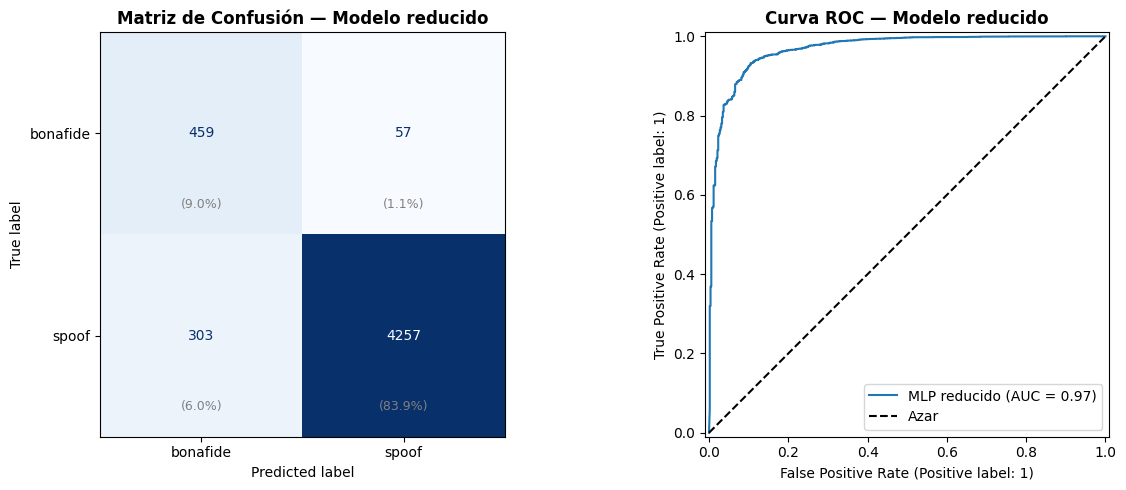

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_new = confusion_matrix(y_test_new, y_pred_new)
ConfusionMatrixDisplay(cm_new, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Modelo reducido', fontweight='bold')

total = cm_new.sum()
for i in range(cm_new.shape[0]):
    for j in range(cm_new.shape[1]):
        axes[0].text(j, i + 0.35, f'({cm_new[i,j]/total*100:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')

RocCurveDisplay.from_predictions(y_test_new, y_prob_new, ax=axes[1], name='MLP reducido')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC — Modelo reducido', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## Comparación de los dos modelos

In [18]:
resultados_comparacion = pd.DataFrame([
    {
        'Modelo': 'MLP — todas las features',
        'N features': len(feature_cols),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
    },
    {
        'Modelo': 'MLP — barra larga (ideal + evaluar)',
        'N features': len(cols_seleccionadas),   # de la selección anterior
        'ROC-AUC': roc_auc_score(y_test_new, y_pred_new),   # ya calculado
        'F1-macro': f1_score(y_test_new, y_pred_new, average='macro'),
    },
])

print(resultados_comparacion.to_string(index=False))


                             Modelo  N features  ROC-AUC  F1-macro
           MLP — todas las features          34 0.989941  0.885142
MLP — barra larga (ideal + evaluar)          12 0.911544  0.838871


Dado que los resultados empeoran, trataremos reducir las features usando el metodo de preprocesamiento RFE. 

## Modelo usando RFE (Recursive Feature Elimination)

RFE entrena el modelo repetidamente, eliminando en cada iteración la feature con menor importancia, dejando solo las features más importantes. 

Preprocesamiento con features RFE

In [26]:
X_rfe = df[cols_rfe].values

X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(
    X_rfe, y, test_size=0.20, random_state=SEED, stratify=y
)

# Balanceo
idx_bon_rfe   = np.where(y_train_rfe == 0)[0]
idx_spoof_rfe = np.where(y_train_rfe == 1)[0]
N = min(2000, len(idx_bon_rfe), len(idx_spoof_rfe))

rng = np.random.default_rng(SEED)
idx_bal_rfe     = np.concatenate([
    rng.choice(idx_bon_rfe,   size=N, replace=False),
    rng.choice(idx_spoof_rfe, size=N, replace=False)
])
X_train_bal_rfe = X_train_rfe[idx_bal_rfe]
y_train_bal_rfe = y_train_rfe[idx_bal_rfe]

scaler_rfe     = StandardScaler()
X_train_sc_rfe = scaler_rfe.fit_transform(X_train_bal_rfe)
X_test_sc_rfe  = scaler_rfe.transform(X_test_rfe)

print(f'Train: {X_train_sc_rfe.shape} | Test: {X_test_sc_rfe.shape}')


Train: (4000, 10) | Test: (5076, 10)


Entrenar modelo reducido

In [21]:
mlp_rfe = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)
mlp_rfe.fit(X_train_sc_rfe, y_train_bal_rfe)
print(f'Épocas entrenadas: {mlp_rfe.n_iter_}')


Épocas entrenadas: 40


Classification Report

In [22]:
y_pred_rfe = mlp_rfe.predict(X_test_sc_rfe)
y_prob_rfe = mlp_rfe.predict_proba(X_test_sc_rfe)[:, 1]

print('=== Classification Report — MLP con RFE (10 features) ===')
print(classification_report(y_test_rfe, y_pred_rfe, target_names=le.classes_))
print(f'ROC-AUC : {roc_auc_score(y_test_rfe, y_prob_rfe):.4f}')
print(f'F1-macro: {f1_score(y_test_rfe, y_pred_rfe, average="macro"):.4f}')


=== Classification Report — MLP con RFE (10 features) ===
              precision    recall  f1-score   support

    bonafide       0.51      0.90      0.65       516
       spoof       0.99      0.90      0.94      4560

    accuracy                           0.90      5076
   macro avg       0.75      0.90      0.80      5076
weighted avg       0.94      0.90      0.91      5076

ROC-AUC : 0.9633
F1-macro: 0.7976


Matriz de confusión y ROC

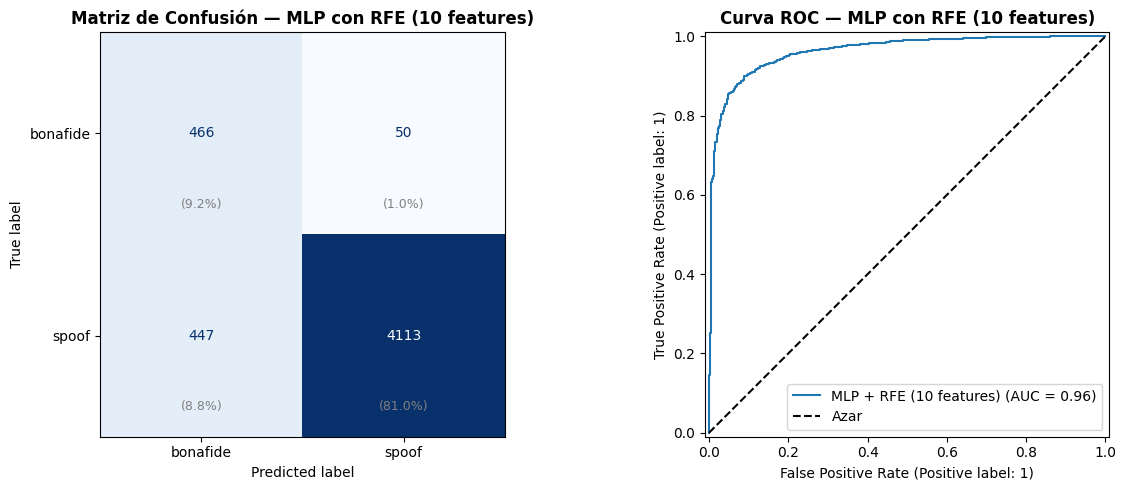

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm_rfe = confusion_matrix(y_test_rfe, y_pred_rfe)
ConfusionMatrixDisplay(cm_rfe, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusión — MLP con RFE (10 features)', fontweight='bold')
total = cm_rfe.sum()
for i in range(cm_rfe.shape[0]):
    for j in range(cm_rfe.shape[1]):
        axes[0].text(j, i + 0.35, f'({cm_rfe[i,j]/total*100:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')

# Curva ROC
RocCurveDisplay.from_predictions(y_test_rfe, y_prob_rfe, ax=axes[1], name='MLP + RFE (10 features)')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('Curva ROC — MLP con RFE (10 features)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## Comparación de los tres Modelos

In [28]:
comparacion = pd.DataFrame([
    {
        'Modelo': 'MLP — todas las features',
        'N features': len(feature_cols),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
    },
    {
        'Modelo': 'MLP — features seleccionadas (permutation)',
        'N features': len(cols_seleccionadas),
        'ROC-AUC': roc_auc_score(y_test_new, y_pred_new),
        'F1-macro': f1_score(y_test_new, y_pred_new, average='macro'),
    },
    {
        'Modelo': 'MLP — RFE (10 features)',
        'N features': len(cols_rfe),
        'ROC-AUC': roc_auc_score(y_test_rfe, y_pred_rfe),
        'F1-macro': f1_score(y_test_rfe, y_pred_rfe, average='macro'),
    },
])
print(comparacion.to_string(index=False))


                                    Modelo  N features  ROC-AUC  F1-macro
                  MLP — todas las features          34 0.989941  0.885142
MLP — features seleccionadas (permutation)          12 0.911544  0.838871
                   MLP — RFE (10 features)          10 0.902537  0.797614


## Conclusión

La selección por Permutation Importance y por RFE disminuyeron el rendimiento del modelo respecto al primero usando todas las features. Esto nos indica que aunque las features que quitamos, individualmente no eran importantes, tomandolas en conjunto contribuyen a la capacidad discriminativa del modelo. Por lo que nos quedaremos con el modelo inicial con todas las features como nuestro mejor modelo.

Y respecto al modleo usando XGBoost, el rendimiento de la Red Neuronla es migeramente superior, por lo que usaremos la Red Neuronal con todas la features como modelo final.